In [31]:
import os
import json
import yaml

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from termcolor import colored, cprint

In [32]:
df = pd.read_csv("../data/processed_results_all.csv")
model_info = pd.read_csv("../data/models_pricing.csv")

In [33]:
def clean_model_name(model_name: str) -> str:
	if "gpt" in model_name or "/o3" in model_name:
		return model_name.split("/")[-1].strip()
	else:
		return model_name.split("openai/")[-1].split("/")[-1].strip().replace("thinking", "").replace("Thinking", "").replace("preview", "").strip(" -")
	
def get_model_family(model_name: str) -> tuple:
	"""
	Returns model family name + version number
	"""
	if "gpt-oss" in model_name:
		return "GPT-OSS", None
	elif "Kimi-" in model_name:
		return "Kimi", None
	elif "GLM" in model_name:
		return "GLM", None
	elif "gemini" in model_name:
		return "Gemini", 3 if "3" in model_name else ("2.5" if "2.5" in model_name else model_name.split("gemini-")[-1].split("-")[0])
	elif "gpt" in model_name:
		return "GPT", model_name.split("gpt-")[-1].split("-")[0]
	elif "gemma" in model_name:
		return "Gemma", model_name.split("gemma-")[-1].split("-")[0]
	elif "Qwen" in model_name:
		return "Qwen", model_name.split("Qwen-")[-1].split("-")[0]
	elif "deepseek" in model_name.lower():
		return "DeepSeek", None
	else:
		return model_name, None

def add_prefix(model_name: str) -> str:
	if "GLM" in model_name:
		return "zai-org/" + model_name
	elif "gemma" in model_name:
		return "google/" + model_name
	elif "Qwen" in model_name:
		return "Qwen/" + model_name
	elif "deepseek" in model_name.lower():
		return "deepseek-ai/" + model_name
	elif "kimi" in model_name.lower():
		return "moonshotai/" + model_name

	elif "gpt-oss" in model_name:
		return "openai/" + model_name
	else:
		print(f"Unknown model name: {model_name}")
		return model_name

In [34]:
# assert not any((df.groupby(["model_name", "qid"])["score"].count() < 4))

df = df.groupby(["model_name", "qtype"])[["score", "error", "price", "out_tokens"]].agg(
	{
		"score": ["mean", "count"],
		"error": ["sum"],
		"price": ["mean", "sum"],
		"out_tokens": ["mean"]
	}
)
df["valid_ratio"] = (df["score"]["count"] - df["error"]["sum"]) / df["score"]["count"]

In [35]:
# Flatten multi-index columns
df.columns = ["_".join(col).strip() for col in df.columns.values]
df = df.reset_index()
df.rename(columns={"score_mean": "accuracy", "price_mean": "avg_price_per_sample"}, inplace=True)

df = pd.merge(df, model_info[["model_name", "size"]], on="model_name", how="left")
df["model_name"] = df["model_name"].apply(clean_model_name)
df["model_family"], df["model_version"] = zip(*df["model_name"].apply(get_model_family))


df.sort_values(["qtype", "accuracy"], inplace=True)

In [36]:
df[df["qtype"] == "image_gen"]

,model_name,qtype,accuracy,score_count,error_sum,avg_price_per_sample,price_sum,out_tokens_mean,valid_ratio_,size,model_family,model_version
44,gpt-image-1-mini,image_gen,0.190476,84,0,3.492540,293.373319,428639.571429,1.0,NaN,GPT,image
15,gemini-2.5-flash-image,image_gen,0.226190,84,0,1.752799,147.235106,58391.642857,1.0,NaN,Gemini,2.5
45,gpt-image-1.5,image_gen,0.404762,84,0,17.254590,1449.385560,531400.821429,1.0,NaN,GPT,image
46,gpt-image-2,image_gen,0.511905,84,0,20.240409,1700.194320,664780.238095,1.0,NaN,GPT,image
21,gemini-3.1-flash-image,image_gen,0.535714,84,0,19.080417,1602.755031,317853.345238,1.0,NaN,Gemini,3
20,gemini-3-pro-image,image_gen,0.547619,84,0,22.053710,1852.511628,183598.154762,1.0,NaN,Gemini,3


In [37]:
df = df[df["qtype"] != "image_gen"]

## Create table

In [38]:
# TODO:

---

## Create plot

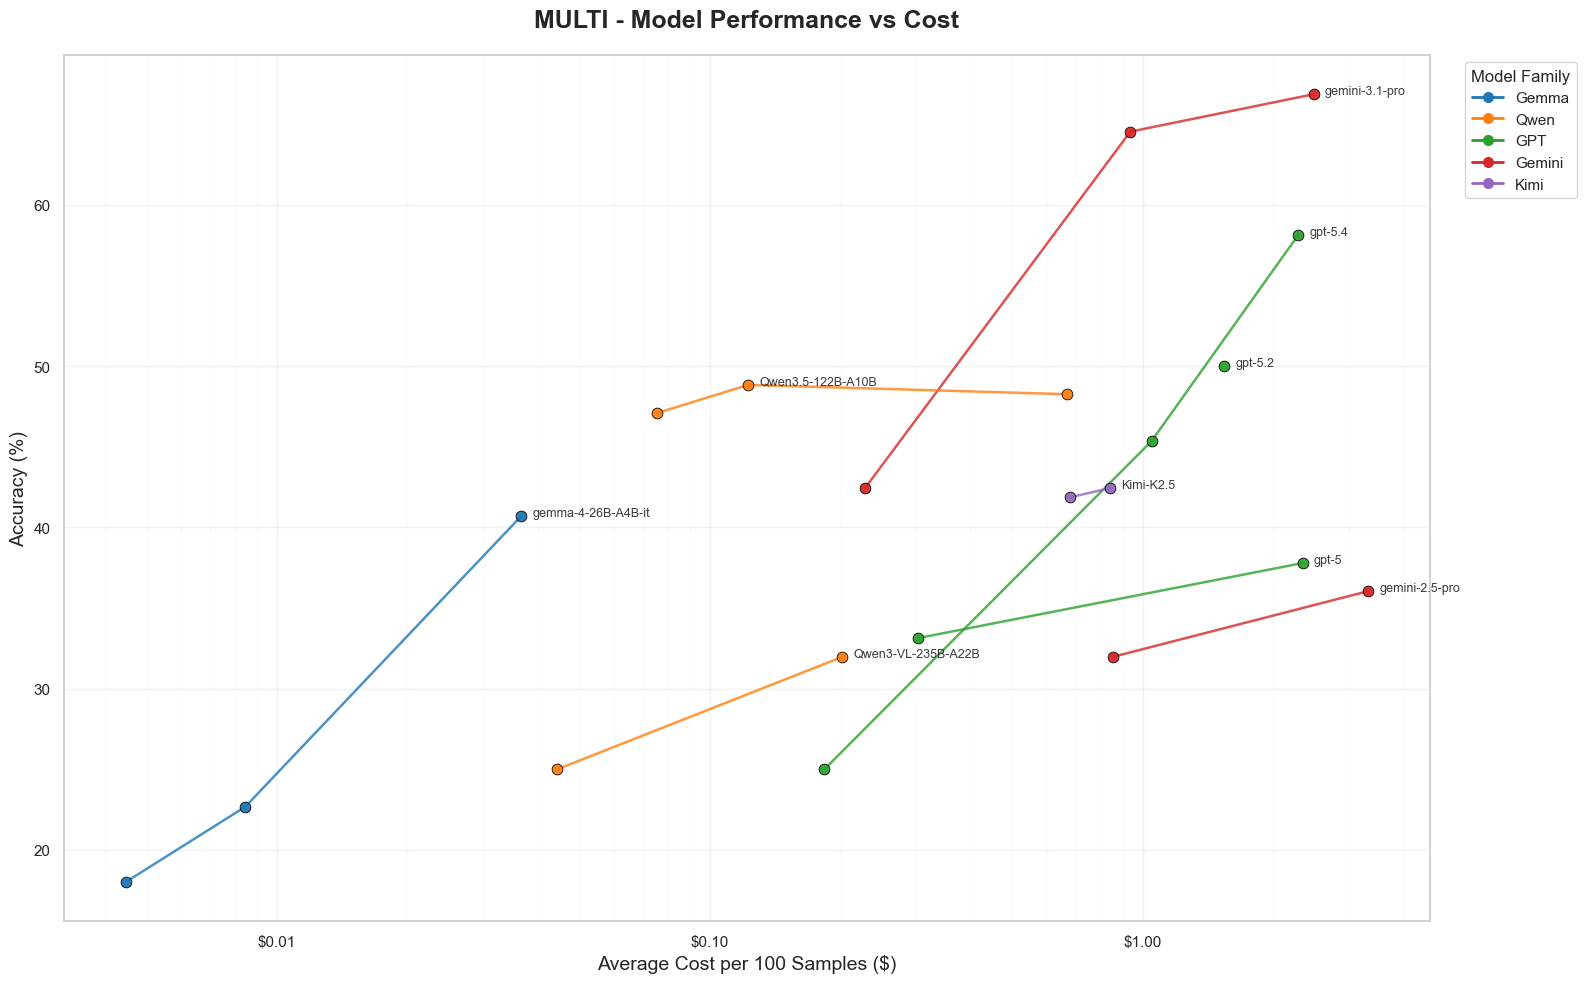

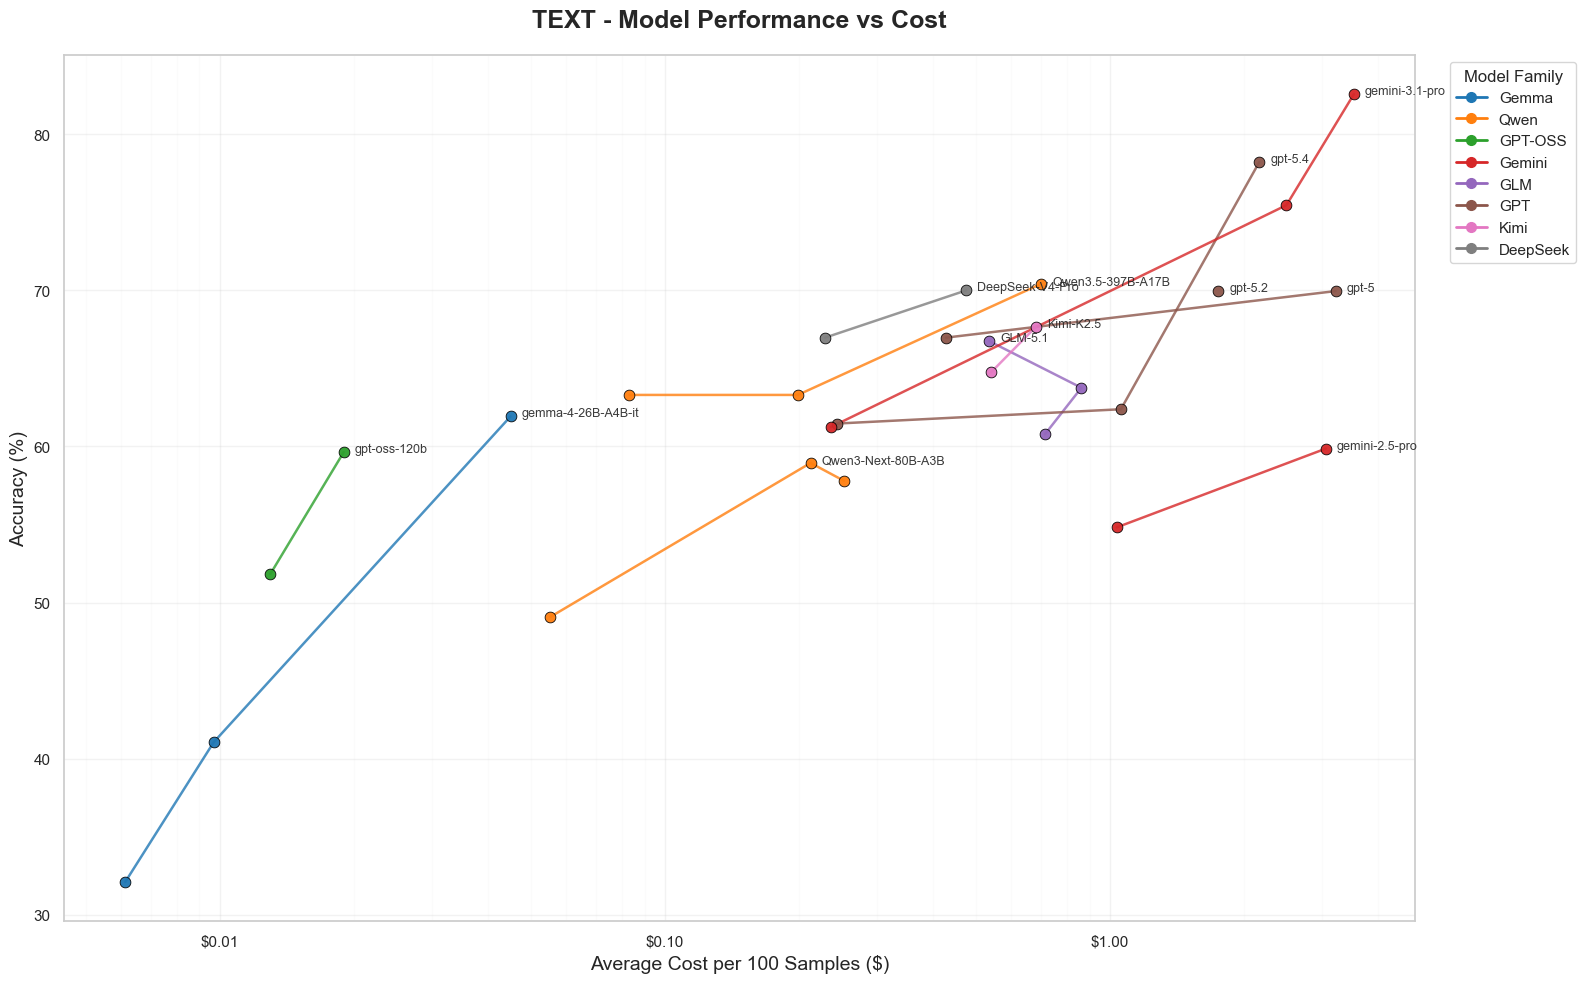

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------------
# CLEANING / PREP
# ------------------------------------------------------------------

for qtype in df["qtype"].unique():
    plot_df = df[df["qtype"] == qtype].copy()

    plot_df["accuracy_pct"] = plot_df["accuracy"] * 100
    plot_df["avg_price_per_100_samples"] = plot_df["avg_price_per_sample"] * 100

    # Group key = manufacturer/family + version
    plot_df["series"] = (
        plot_df["model_family"].astype(str)
        + " "
        + plot_df["model_version"].astype(str)
    )

    plot_df = plot_df.dropna(
        subset=["accuracy_pct", "avg_price_per_100_samples"]
    ).copy()

    # Sort lines by model size if available, otherwise by cost
    plot_df["sort_key"] = np.where(
        plot_df["size"].notna(),
        plot_df["size"],
        plot_df["avg_price_per_100_samples"]
    )

    # ------------------------------------------------------------------
    # STYLING
    # ------------------------------------------------------------------
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(16, 10))

    families = plot_df["model_family"].dropna().unique()
    palette = sns.color_palette("tab10", n_colors=len(families))
    family_colors = dict(zip(families, palette))

    # ------------------------------------------------------------------
    # DRAW CONNECTED SERIES
    # ------------------------------------------------------------------
    for series_name, g in plot_df.groupby("series"):
        g = g.sort_values("sort_key")

        fam = g["model_family"].iloc[0]
        color = family_colors.get(fam, "gray")

        # connected line
        ax.plot(
            g["avg_price_per_100_samples"],
            g["accuracy_pct"],
            lw=1.8,
            alpha=0.8,
            color=color,
            zorder=1
        )

        # scatter points
        ax.scatter(
            g["avg_price_per_100_samples"],
            g["accuracy_pct"],
            s=60,
            color=color,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.95,
            zorder=2
        )

    # ------------------------------------------------------------------
    # LABEL BEST POINT OF EACH SERIES (optional)
    # ------------------------------------------------------------------
    for series_name, g in plot_df.groupby("series"):
        best = g.loc[g["accuracy_pct"].idxmax()]

        ax.annotate(
            best["model_name"],
            xy=(best["avg_price_per_100_samples"], best["accuracy_pct"]),
            xytext=(8, 0),
            textcoords="offset points",
            fontsize=9,
            alpha=0.9
        )

    # ------------------------------------------------------------------
    # AXES
    # ------------------------------------------------------------------
    ax.set_xscale("log")

    ax.set_xlabel("Average Cost per 100 Samples ($)", fontsize=14)
    ax.set_ylabel("Accuracy (%)", fontsize=14)
    ax.set_title(
        f"{qtype.upper()} - Model Performance vs Cost",
        fontsize=18,
        weight="bold",
        pad=20
    )

    # ax.set_ylim(0, 100)

    # Format x-axis as dollars
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"${x:.4f}" if x < 0.01 else f"${x:.2f}")
    )

    # ------------------------------------------------------------------
    # LEGEND (one entry per family)
    # ------------------------------------------------------------------
    handles = []
    labels = []

    for fam in families:
        h = plt.Line2D(
            [0], [0],
            color=family_colors[fam],
            marker="o",
            lw=2,
            markersize=7
        )
        handles.append(h)
        labels.append(fam)

    ax.legend(
        handles,
        labels,
        title="Model Family",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True
    )

    # ------------------------------------------------------------------
    # GRID / LAYOUT
    # ------------------------------------------------------------------
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.08)

    plt.tight_layout()
    plt.show()

In [40]:
import requests
import pandas as pd

aai_index_path = "../data/artificial_analysis_intelligence_index.csv"

if not os.path.exists(aai_index_path):
    API_KEY = os.getenv("ARTIFICIAL_ANALYSIS_API_KEY")

    url = "https://artificialanalysis.ai/api/v2/data/llms/models"
    headers = {"x-api-key": API_KEY}

    r = requests.get(url, headers=headers)
    r.raise_for_status()

    models = r.json()["data"]

    rows = []
    for m in models:
        evals = m.get("evaluations", {})

        rows.append({
            "model_id": m.get("id"),
            "model_name": m.get("name"),
            "creator": m.get("model_creator", {}).get("name"),
            "aa_intelligence_index": evals.get("artificial_analysis_intelligence_index"),
            "aa_coding_index": evals.get("artificial_analysis_coding_index"),
            "aa_math_index": evals.get("artificial_analysis_math_index"),
        })

    aai_index = pd.DataFrame(rows)
    aai_index.to_csv(aai_index_path, index=False)
else:
    aai_index = pd.read_csv(aai_index_path)
    aai_index_dict = {}
    for _, row in aai_index.iterrows():
        aai_index_dict[row["model_name"]] = row["aa_intelligence_index"]

In [41]:
mapping = {
    # OpenAI reasoning models, medium effort where available
    "gpt-5.4-mini": aai_index_dict.get("GPT-5.4 mini (medium)", None),
    "gpt-5.4-nano": aai_index_dict.get("GPT-5.4 nano (medium)", None),
    "gpt-5.2": aai_index_dict.get("GPT-5.2 (medium)", None),
    "gpt-5": aai_index_dict.get("GPT-5 (medium)", None),
    "gpt-5-mini": aai_index_dict.get("GPT-5 mini (medium)", None),
	# missing values, use proxy
    "gpt-5.4": (aai_index_dict["GPT-5.4 (xhigh)"] + aai_index_dict["GPT-5.4 (Non-reasoning)"]) / 2, # proxy for medium effort
    "gpt-oss-120b": (aai_index_dict["gpt-oss-120B (high)"] + aai_index_dict["gpt-oss-120B (low)"]) / 2, # proxy for medium effort,
    "gpt-oss-20b": (aai_index_dict["gpt-oss-20B (high)"] + aai_index_dict["gpt-oss-20B (low)"]) / 2, # proxy for medium effort,

    # Google / Gemini / Gemma
    "gemini-3.1-pro": aai_index_dict.get("Gemini 3.1 Pro Preview", None),
    "gemini-3-flash": aai_index_dict.get("Gemini 3 Flash Preview (Reasoning)", None),
    "gemini-3.1-flash-lite": aai_index_dict.get("Gemini 3.1 Flash-Lite Preview", None),
    "gemini-2.5-pro": aai_index_dict.get("Gemini 2.5 Pro", None),
    "gemini-2.5-flash": aai_index_dict.get("Gemini 2.5 Flash (Reasoning)", None),
    "gemma-4-31B-it": aai_index_dict.get("Gemma 4 31B (Reasoning)", None),
    "gemma-4-26B-A4B-it": aai_index_dict.get("Gemma 4 26B A4B (Reasoning)", None),
    "gemma-4-E4B-it": aai_index_dict.get("Gemma 4 E4B (Reasoning)", None),
    "gemma-4-E2B-it": aai_index_dict.get("Gemma 4 E2B (Reasoning)", None),

    # Qwen reasoning models
    "Qwen3.5-397B-A17B": aai_index_dict.get("Qwen3.5 397B A17B (Reasoning)", None),
    "Qwen3.5-122B-A10B": aai_index_dict.get("Qwen3.5 122B A10B (Reasoning)", None),
    "Qwen3.5-35B-A3B": aai_index_dict.get("Qwen3.5 35B A3B (Reasoning)", None),
    "Qwen3-VL-235B-A22B": aai_index_dict.get("Qwen3 VL 235B A22B (Reasoning)", None),
    "Qwen3-Next-80B-A3B": aai_index_dict.get("Qwen3 Next 80B A3B (Reasoning)", None),
    "Qwen3-VL-30B-A3B": aai_index_dict.get("Qwen3 VL 30B A3B (Reasoning)", None),

    # Kimi
    "Kimi-K2.6": aai_index_dict.get("Kimi K2.6", None),
    "Kimi-K2.5": aai_index_dict.get("Kimi K2.5 (Reasoning)", None),
	
    # Zhipu / GLM
    "GLM-5.1": aai_index_dict.get("GLM-5.1 (Reasoning)", None),
    "GLM-4.7": aai_index_dict.get("GLM-4.7 (Reasoning)", None),
    "GLM-5": aai_index_dict.get("GLM-5 (Reasoning)", None),

    # DeepSeek
    "DeepSeek-V4-Pro": aai_index_dict.get("DeepSeek V4 Pro (Reasoning, High Effort)", None),
    "DeepSeek-V4-Flash": aai_index_dict.get("DeepSeek V4 Flash (Reasoning, High Effort)", None),
}

df["aa_intelligence_index"] = df["model_name"].map(mapping)

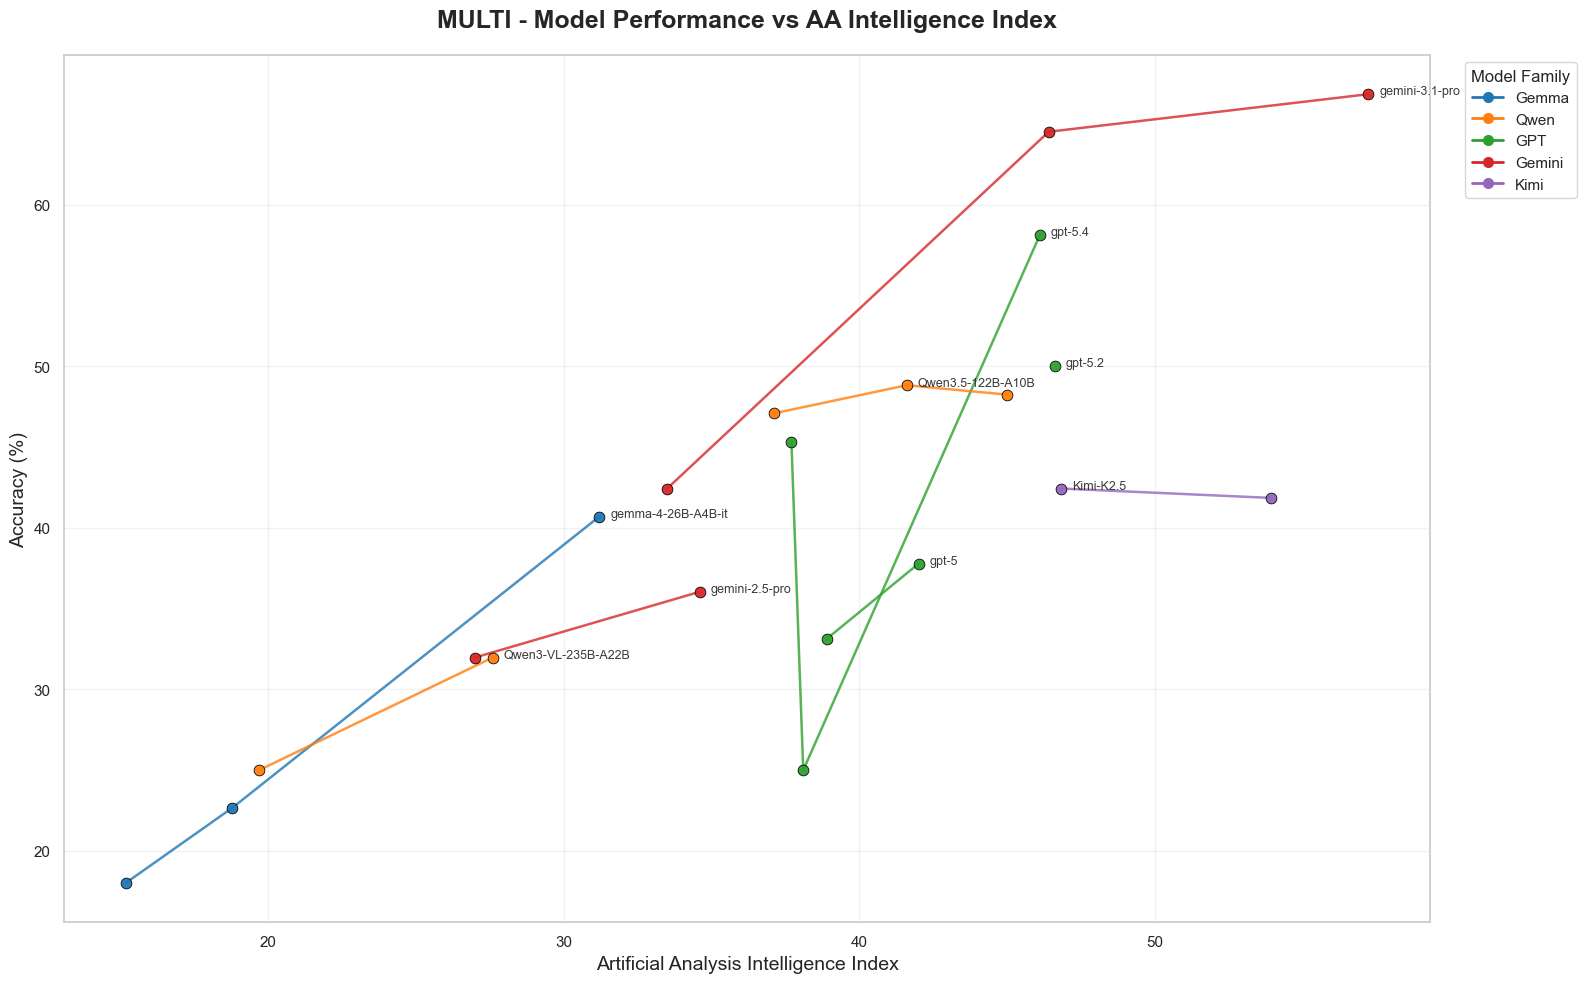

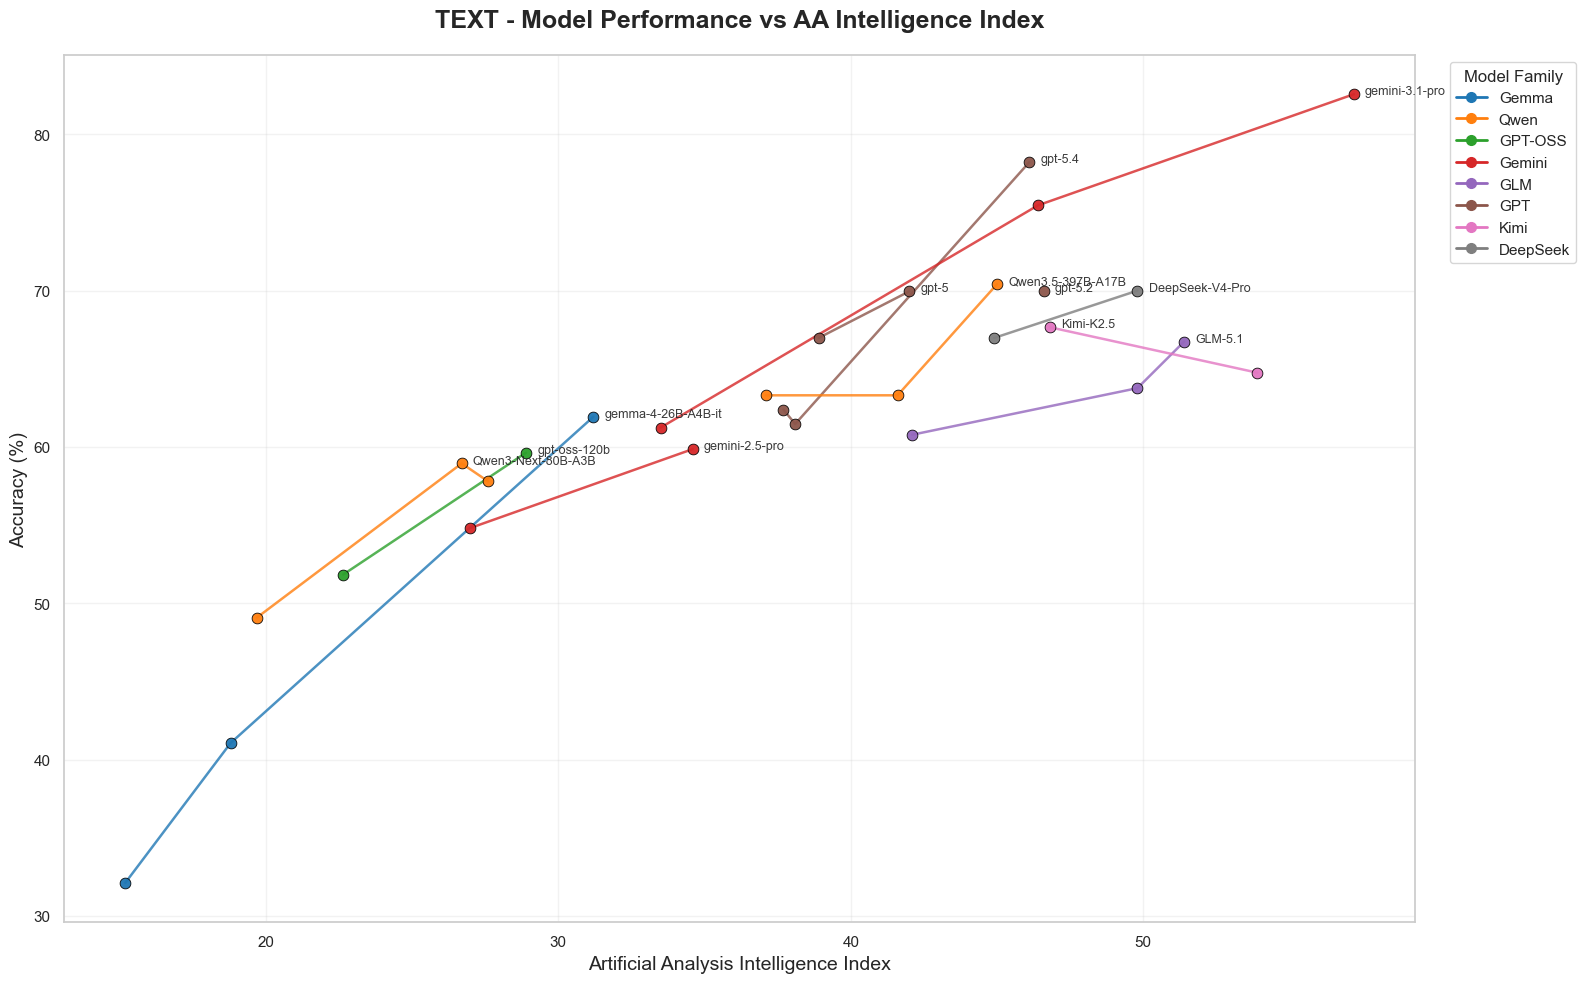

In [42]:
for qtype in df["qtype"].unique():
    plot_df = df[df["qtype"] == qtype].copy()

    plot_df["accuracy_pct"] = plot_df["accuracy"] * 100

    # Group key = manufacturer/family + version
    plot_df["series"] = (
        plot_df["model_family"].astype(str)
        + " "
        + plot_df["model_version"].astype(str)
    )

    plot_df = plot_df.dropna(
        subset=["accuracy_pct", "aa_intelligence_index"]
    ).copy()

    # Sort lines by model size if available, otherwise by intelligence index
    plot_df["sort_key"] = np.where(
        plot_df["size"].notna(),
        plot_df["size"],
        plot_df["aa_intelligence_index"]
    )

    # ------------------------------------------------------------------
    # STYLING
    # ------------------------------------------------------------------
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(16, 10))

    families = plot_df["model_family"].dropna().unique()
    palette = sns.color_palette("tab10", n_colors=len(families))
    family_colors = dict(zip(families, palette))

    # ------------------------------------------------------------------
    # DRAW CONNECTED SERIES
    # ------------------------------------------------------------------
    for series_name, g in plot_df.groupby("series"):
        g = g.sort_values("sort_key")

        fam = g["model_family"].iloc[0]
        color = family_colors.get(fam, "gray")

        # connected line
        ax.plot(
            g["aa_intelligence_index"],
            g["accuracy_pct"],
            lw=1.8,
            alpha=0.8,
            color=color,
            zorder=1
        )

        # scatter points
        ax.scatter(
            g["aa_intelligence_index"],
            g["accuracy_pct"],
            s=60,
            color=color,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.95,
            zorder=2
        )

    # ------------------------------------------------------------------
    # LABEL BEST POINT OF EACH SERIES (optional)
    # ------------------------------------------------------------------
    for series_name, g in plot_df.groupby("series"):
        best = g.loc[g["accuracy_pct"].idxmax()]

        ax.annotate(
            best["model_name"],
            xy=(best["aa_intelligence_index"], best["accuracy_pct"]),
            xytext=(8, 0),
            textcoords="offset points",
            fontsize=9,
            alpha=0.9
        )

    # ------------------------------------------------------------------
    # AXES
    # ------------------------------------------------------------------
    ax.set_xlabel("Artificial Analysis Intelligence Index", fontsize=14)
    ax.set_ylabel("Accuracy (%)", fontsize=14)
    ax.set_title(
        f"{qtype.upper()} - Model Performance vs AA Intelligence Index",
        fontsize=18,
        weight="bold",
        pad=20
    )

    # ax.set_ylim(0, 100)

    # ------------------------------------------------------------------
    # LEGEND (one entry per family)
    # ------------------------------------------------------------------
    handles = []
    labels = []

    for fam in families:
        h = plt.Line2D(
            [0], [0],
            color=family_colors[fam],
            marker="o",
            lw=2,
            markersize=7
        )
        handles.append(h)
        labels.append(fam)

    ax.legend(
        handles,
        labels,
        title="Model Family",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True
    )

    # ------------------------------------------------------------------
    # GRID / LAYOUT
    # ------------------------------------------------------------------
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.08)

    plt.tight_layout()
    plt.show()